# Examples: Data Processing

This is a trivial example of how to create data for CNSistent, fill missing segments, impute missing values, create consistent segmentation, aggregate the values and plot the results.

## Create data

In [2]:
import io
import cns
import pandas as pd
cns_source = """sample_id, chrom, start, end, CN1, CN2
s1, chr19, 1000000, 3000000, 1,
s1, chr19, 3000000, 12000000, 1, 1
s1, chr19, 12000000, 14000000, , 1
s1, chr19, 14000000, 21000000, 3, 1
s1, chr19, 21000000, 25000000, 3, 
s1, chr19, 28000000, 58500000, 3,
s2, chr19, 1000000, 24000000, 2,
s2, chr19, 29000000, 58000000, 0,
"""
raw_cns_df = pd.read_csv(io.StringIO(cns_source.strip()), sep=',\s*', engine='python')
print(raw_cns_df.head())

  sample_id  chrom     start       end  CN1  CN2
0        s1  chr19   1000000   3000000  1.0  NaN
1        s1  chr19   3000000  12000000  1.0  1.0
2        s1  chr19  12000000  14000000  NaN  1.0
3        s1  chr19  14000000  21000000  3.0  1.0
4        s1  chr19  21000000  25000000  3.0  NaN


## Fill and impute

Create missing segments with NaN values.

In [ ]:
fill_cns_df = cns.main_fill(raw_cns_df, add_missing_chromosomes=False)
print(fill_cns_df.head())

  sample_id  chrom     start       end  CN1  CN2
0        s1  chr19         0   1000000  NaN  NaN
1        s1  chr19   1000000   3000000  1.0  NaN
2        s1  chr19   3000000  12000000  1.0  1.0
3        s1  chr19  12000000  14000000  NaN  1.0
4        s1  chr19  14000000  21000000  3.0  1.0


Fill values into the missing segments. Leading and trailing NaN values are filled with the first and last non-NaN value, respectively. The remaining NaN values are filled with the mean of the non-NaN values.

In [4]:
imp_cns_df = cns.main_impute(fill_cns_df)
print(imp_cns_df.head())

  sample_id  chrom     start       end  CN1  CN2
0        s1  chr19         0  13000000    1    1
1        s1  chr19  13000000  59128983    3    1
2        s2  chr19         0  26500000    2    0
3        s2  chr19  26500000  59128983    0    0


## Segment and aggregate

Create consistent segmentation.

In [34]:
segs = cns.main_segment(fill_cns_df, merge_dist=0, remove_segs="gaps")
segs["chr19"]

[(0, 1000000.0, 'chr19'),
 (1000000.0, 3000000.0, 'chr19'),
 (3000000.0, 12000000.0, 'chr19'),
 (12000000.0, 14000000.0, 'chr19'),
 (14000000.0, 21000000.0, 'chr19'),
 (21000000.0, 24000000.0, 'chr19'),
 (24000000.0, 25000000.0, 'chr19'),
 (25000000.0, 28000000.0, 'chr19'),
 (28000000.0, 29000000.0, 'chr19'),
 (29000000.0, 58000000.0, 'chr19'),
 (58000000.0, 58500000.0, 'chr19'),
 (58500000.0, 59128983, 'chr19')]

In [35]:
agg_cns_df = cns.main_aggregate(fill_cns_df, segs)
agg_cns_df

WARN: NaNs are not considered in aggregation calculations; it is recommended to impute first.


,sample_id,chrom,start,end,CN1,CN2,name
0,s1,chr19,0,1000000,0.0,0.0,chr19
1,s1,chr19,1000000,3000000,1.0,0.0,chr19
2,s1,chr19,3000000,12000000,1.0,1.0,chr19
3,s1,chr19,12000000,14000000,0.0,1.0,chr19
4,s1,chr19,14000000,21000000,3.0,1.0,chr19
5,s1,chr19,21000000,24000000,3.0,0.0,chr19
6,s1,chr19,24000000,25000000,3.0,0.0,chr19
7,s1,chr19,25000000,28000000,0.0,0.0,chr19
8,s1,chr19,28000000,29000000,3.0,0.0,chr19
9,s1,chr19,29000000,58000000,3.0,0.0,chr19


In [29]:
agg_cns_df

,sample_id,chrom,start,end,CN1,CN2,name
0,s1,chr19,0,13000000,1.0,1.0,chr19
1,s1,chr19,13000000,26500000,3.0,1.0,chr19
2,s1,chr19,26500000,59128983,3.0,1.0,chr19
3,s2,chr19,0,13000000,2.0,0.0,chr19
4,s2,chr19,13000000,26500000,2.0,0.0,chr19
5,s2,chr19,26500000,59128983,0.0,0.0,chr19


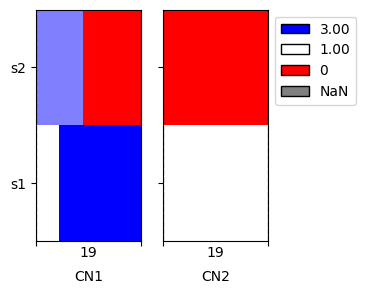

In [30]:
cns.fig_heatmap(agg_cns_df, cn_columns=['CN1', 'CN2']);

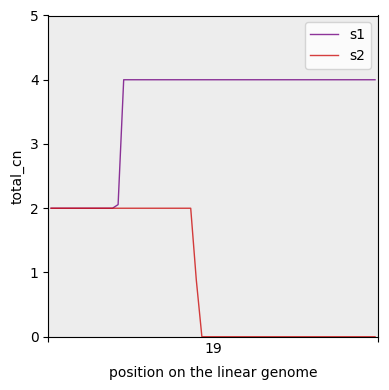

In [ ]:
split_df = cns.main_seg_agg(fill_cns_df, split_size=1000000, remove_segs="gaps")
cns.fig_lines(cns.add_total_cn(split_df), cn_columns="total_cn");